# Notebook 01 — EDA & Preprocessing — LIAR Dataset

**Objectif** : Explorer le LIAR Dataset, comprendre la distribution des labels et des métadonnées, puis nettoyer et préparer les données pour la modélisation.

**Pipeline :**
1. Chargement des données brutes
2. EDA complète (textes, métadonnées, compteurs, valeurs manquantes)
3. Preprocessing (nettoyage texte, encodage labels)
4. Export vers `02_stg/`

## 0. Installation des dépendances

In [1]:
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('omw-1.4', quiet=True)

print('Dépendances et ressources NLTK prêtes.')

[nltk_data] Zip Slip blocked: stopwords/
[nltk_data] Zip Slip blocked: punkt/


Dépendances et ressources NLTK prêtes.


## 0.1 Imports globaux

In [2]:
import os
import re
import string
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

try:
    from wordcloud import WordCloud
    WORDCLOUD_AVAILABLE = True
except ImportError:
    WORDCLOUD_AVAILABLE = False
    print('wordcloud non disponible — utilisation de barplots à la place.')

# Style global
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.titlesize'] = 13

# Chemins relatifs à la racine du projet
ROOT = Path('..').resolve()
RAW_DIR = ROOT / 'LIAR_DATA_SET' / '01_raw'
STG_DIR = ROOT / 'LIAR_DATA_SET' / '02_stg'
STG_DIR.mkdir(parents=True, exist_ok=True)

print(f'Racine projet : {ROOT}')
print(f'Données brutes : {RAW_DIR}')
print(f'Staging       : {STG_DIR}')

Racine projet : C:\Users\HugoG\Documents\GitHub\projet_spe_3_fake_new
Données brutes : C:\Users\HugoG\Documents\GitHub\projet_spe_3_fake_new\LIAR_DATA_SET\01_raw
Staging       : C:\Users\HugoG\Documents\GitHub\projet_spe_3_fake_new\LIAR_DATA_SET\02_stg


---
# ÉTAPE 1 — Chargement des données brutes

In [3]:
# Noms des 14 colonnes du LIAR Dataset
COLUMNS = [
    'id', 'label', 'statement', 'subject', 'speaker', 'job_title',
    'state', 'party', 'barely_true_counts', 'false_counts',
    'half_true_counts', 'mostly_true_counts', 'pants_fire_counts', 'context'
]

# Chargement des trois splits
train = pd.read_csv(RAW_DIR / 'train.tsv', sep='\t', header=None, names=COLUMNS)
test  = pd.read_csv(RAW_DIR / 'test.tsv',  sep='\t', header=None, names=COLUMNS)
valid = pd.read_csv(RAW_DIR / 'valid.tsv', sep='\t', header=None, names=COLUMNS)

splits = {'train': train, 'test': test, 'valid': valid}

print('=== Shapes ===' )
for name, df in splits.items():
    print(f'  {name:6s} : {df.shape}')

=== Shapes ===
  train  : (10240, 14)
  test   : (1267, 14)
  valid  : (1284, 14)


In [4]:
# Types de colonnes
print('=== Types (train) ===')
print(train.dtypes)

=== Types (train) ===
id                        str
label                     str
statement                 str
subject                   str
speaker                   str
job_title                 str
state                     str
party                     str
barely_true_counts    float64
false_counts          float64
half_true_counts      float64
mostly_true_counts    float64
pants_fire_counts     float64
context                   str
dtype: object


In [5]:
# Aperçu des 5 premières lignes de chaque split
for name, df in splits.items():
    print(f'\n=== {name.upper()} — 5 premières lignes ===')
    display(df.head())


=== TRAIN — 5 premières lignes ===


,id,label,statement,subject,speaker,job_title,state,party,barely_true_counts,false_counts,half_true_counts,mostly_true_counts,pants_fire_counts,context
0,2635.json,false,Says the Annies List political group supports ...,abortion,dwayne-bohac,State representative,Texas,republican,0.0,1.0,0.0,0.0,0.0,a mailer
1,10540.json,half-true,When did the decline of coal start? It started...,"energy,history,job-accomplishments",scott-surovell,State delegate,Virginia,democrat,0.0,0.0,1.0,1.0,0.0,a floor speech.
2,324.json,mostly-true,"Hillary Clinton agrees with John McCain ""by vo...",foreign-policy,barack-obama,President,Illinois,democrat,70.0,71.0,160.0,163.0,9.0,Denver
3,1123.json,false,Health care reform legislation is likely to ma...,health-care,blog-posting,NaN,NaN,none,7.0,19.0,3.0,5.0,44.0,a news release
4,9028.json,half-true,The economic turnaround started at the end of ...,"economy,jobs",charlie-crist,NaN,Florida,democrat,15.0,9.0,20.0,19.0,2.0,an interview on CNN



=== TEST — 5 premières lignes ===


,id,label,statement,subject,speaker,job_title,state,party,barely_true_counts,false_counts,half_true_counts,mostly_true_counts,pants_fire_counts,context
0,11972.json,true,Building a wall on the U.S.-Mexico border will...,immigration,rick-perry,Governor,Texas,republican,30,30,42,23,18,Radio interview
1,11685.json,false,Wisconsin is on pace to double the number of l...,jobs,katrina-shankland,State representative,Wisconsin,democrat,2,1,0,0,0,a news conference
2,11096.json,false,Says John McCain has done nothing to help the ...,"military,veterans,voting-record",donald-trump,President-Elect,New York,republican,63,114,51,37,61,comments on ABC's This Week.
3,5209.json,half-true,Suzanne Bonamici supports a plan that will cut...,"medicare,message-machine-2012,campaign-adverti...",rob-cornilles,consultant,Oregon,republican,1,1,3,1,1,a radio show
4,9524.json,pants-fire,When asked by a reporter whether hes at the ce...,"campaign-finance,legal-issues,campaign-adverti...",state-democratic-party-wisconsin,NaN,Wisconsin,democrat,5,7,2,2,7,a web video



=== VALID — 5 premières lignes ===


,id,label,statement,subject,speaker,job_title,state,party,barely_true_counts,false_counts,half_true_counts,mostly_true_counts,pants_fire_counts,context
0,12134.json,barely-true,We have less Americans working now than in the...,"economy,jobs",vicky-hartzler,U.S. Representative,Missouri,republican,1,0,1,0,0,an interview with ABC17 News
1,238.json,pants-fire,"When Obama was sworn into office, he DID NOT u...","obama-birth-certificate,religion",chain-email,NaN,NaN,none,11,43,8,5,105,NaN
2,7891.json,false,Says Having organizations parading as being so...,"campaign-finance,congress,taxes",earl-blumenauer,U.S. representative,Oregon,democrat,0,1,1,1,0,a U.S. Ways and Means hearing
3,8169.json,half-true,Says nearly half of Oregons children are poor.,poverty,jim-francesconi,Member of the State Board of Higher Education,Oregon,none,0,1,1,1,0,an opinion article
4,929.json,half-true,On attacks by Republicans that various program...,"economy,stimulus",barack-obama,President,Illinois,democrat,70,71,160,163,9,interview with CBS News


---
# ÉTAPE 2 — EDA complète

## 2.1 Distribution des labels

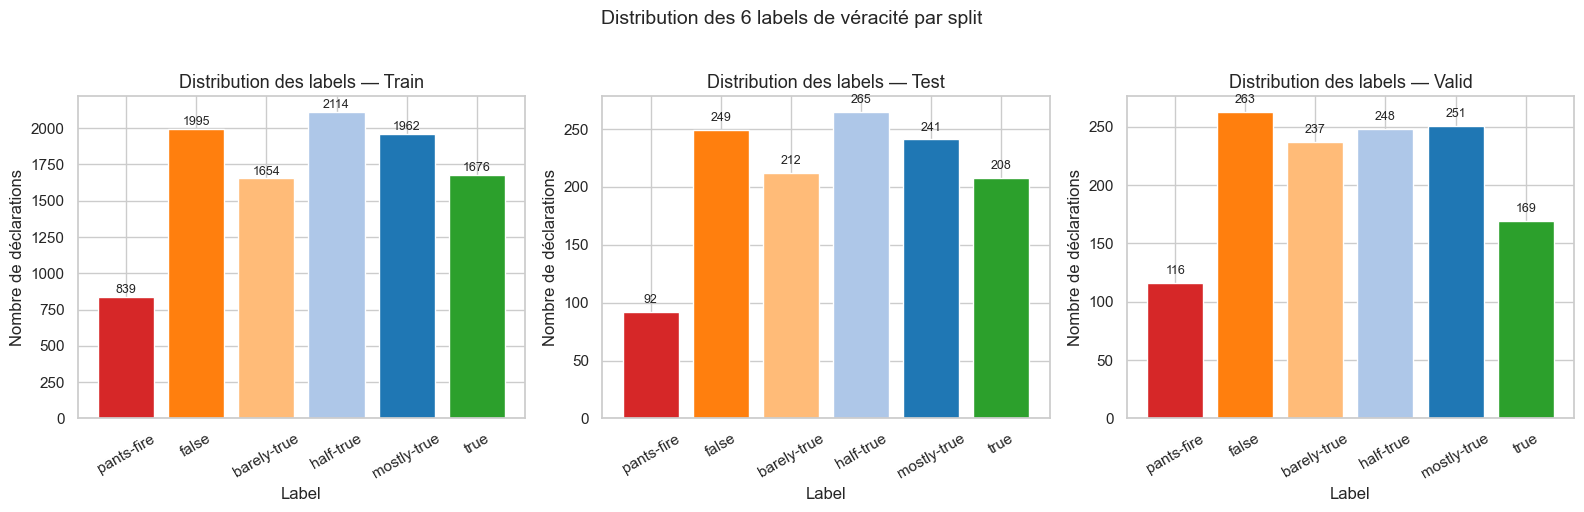

In [6]:
# Ordre cohérent des labels (du plus faux au plus vrai)
LABEL_ORDER = ['pants-fire', 'false', 'barely-true', 'half-true', 'mostly-true', 'true']
LABEL_COLORS = ['#d62728', '#ff7f0e', '#ffbb78', '#aec7e8', '#1f77b4', '#2ca02c']

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)

for ax, (name, df) in zip(axes, splits.items()):
    counts = df['label'].value_counts().reindex(LABEL_ORDER, fill_value=0)
    bars = ax.bar(counts.index, counts.values, color=LABEL_COLORS, edgecolor='white')
    ax.set_title(f'Distribution des labels — {name.capitalize()}')
    ax.set_xlabel('Label')
    ax.set_ylabel('Nombre de déclarations')
    ax.tick_params(axis='x', rotation=30)
    # Afficher les valeurs au-dessus des barres
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
                str(int(bar.get_height())), ha='center', va='bottom', fontsize=9)

plt.suptitle('Distribution des 6 labels de véracité par split', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [7]:
# Ratio de déséquilibre : classe majoritaire / classe minoritaire
print('=== Ratio de déséquilibre (majoritaire / minoritaire) ===')
for name, df in splits.items():
    counts = df['label'].value_counts()
    ratio = counts.max() / counts.min()
    print(f'  {name:6s} : max={counts.max()} ({counts.idxmax()}), '
          f'min={counts.min()} ({counts.idxmin()}), ratio={ratio:.2f}')

=== Ratio de déséquilibre (majoritaire / minoritaire) ===
  train  : max=2114 (half-true), min=839 (pants-fire), ratio=2.52
  test   : max=265 (half-true), min=92 (pants-fire), ratio=2.88
  valid  : max=263 (false), min=116 (pants-fire), ratio=2.27


## 2.2 Analyse des textes

In [8]:
# Calcul des longueurs (mots et caractères) sur le split train
train['word_count'] = train['statement'].dropna().apply(lambda x: len(str(x).split()))
train['char_count'] = train['statement'].dropna().apply(lambda x: len(str(x)))

print('=== Statistiques de longueur des statements (train) ===')
print(train[['word_count', 'char_count']].describe().round(1))

=== Statistiques de longueur des statements (train) ===
       word_count  char_count
count     10240.0     10240.0
mean         18.0       106.9
std           9.7        59.9
min           2.0        11.0
25%          12.0        73.0
50%          17.0        99.0
75%          22.0       132.2
max         467.0      3192.0


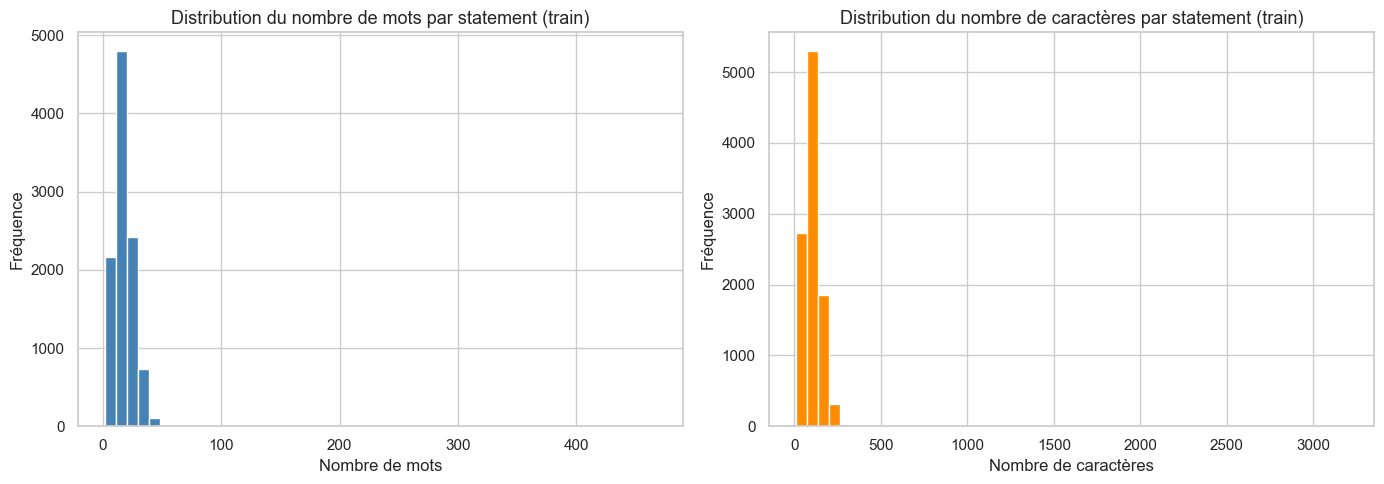

In [9]:
# Histogrammes de longueur
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(train['word_count'].dropna(), bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution du nombre de mots par statement (train)')
axes[0].set_xlabel('Nombre de mots')
axes[0].set_ylabel('Fréquence')

axes[1].hist(train['char_count'].dropna(), bins=50, color='darkorange', edgecolor='white')
axes[1].set_title('Distribution du nombre de caractères par statement (train)')
axes[1].set_xlabel('Nombre de caractères')
axes[1].set_ylabel('Fréquence')

plt.tight_layout()
plt.show()

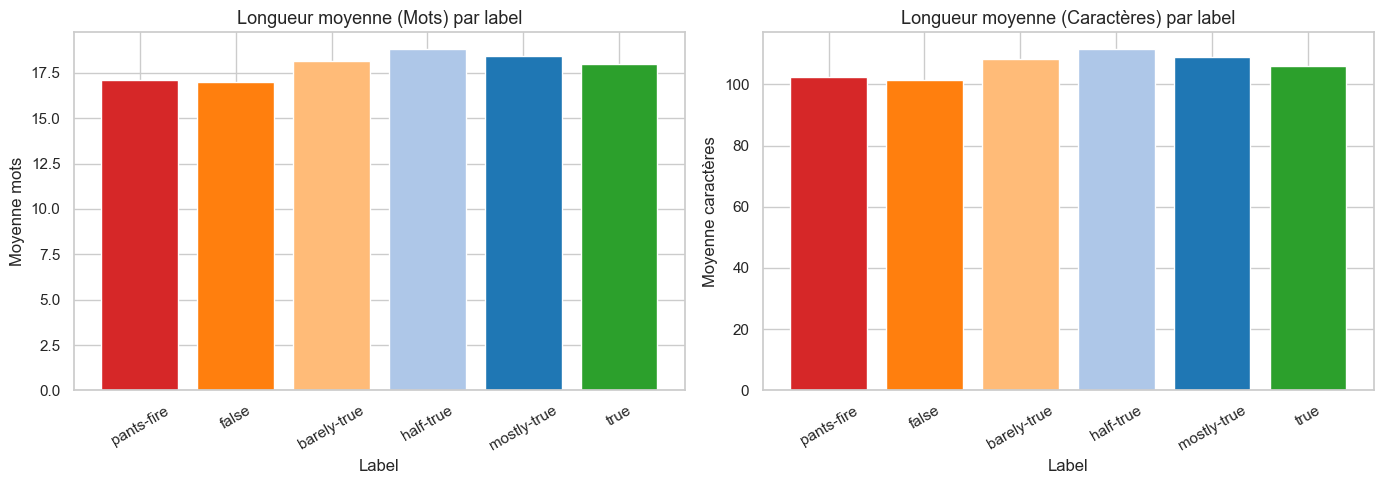

In [10]:
# Longueur moyenne des statements par label
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, title in zip(
    axes,
    ['word_count', 'char_count'],
    ['Mots', 'Caractères']
):
    means = (train.groupby('label')[col]
             .mean()
             .reindex(LABEL_ORDER)
             .dropna())
    ax.bar(means.index, means.values, color=LABEL_COLORS, edgecolor='white')
    ax.set_title(f'Longueur moyenne ({title}) par label')
    ax.set_xlabel('Label')
    ax.set_ylabel(f'Moyenne {title.lower()}')
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

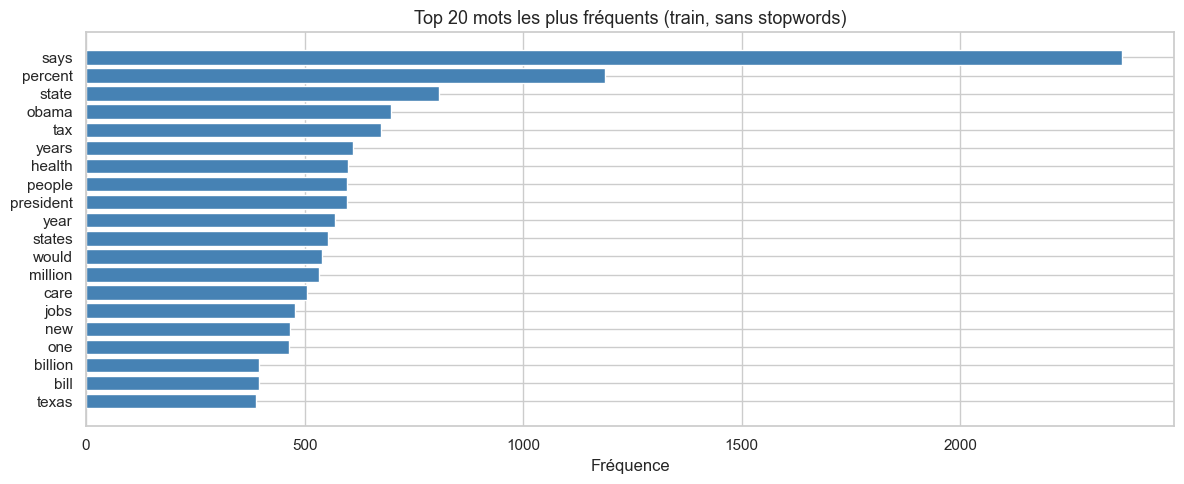

In [11]:
# Top 20 mots les plus fréquents (après suppression des stopwords)
stop_words = set(stopwords.words('english'))

def tokenize_no_stop(text):
    """Tokenise un texte et retire les stopwords et la ponctuation."""
    tokens = re.sub(r'[^a-zA-Z\s]', '', str(text).lower()).split()
    return [t for t in tokens if t not in stop_words and len(t) > 2]

# Concaténation de tous les tokens du train
all_tokens = []
for stmt in train['statement'].dropna():
    all_tokens.extend(tokenize_no_stop(stmt))

top20 = Counter(all_tokens).most_common(20)
words_top20, counts_top20 = zip(*top20)

fig, ax = plt.subplots(figsize=(12, 5))
ax.barh(list(reversed(words_top20)), list(reversed(counts_top20)), color='steelblue')
ax.set_title('Top 20 mots les plus fréquents (train, sans stopwords)')
ax.set_xlabel('Fréquence')
plt.tight_layout()
plt.show()

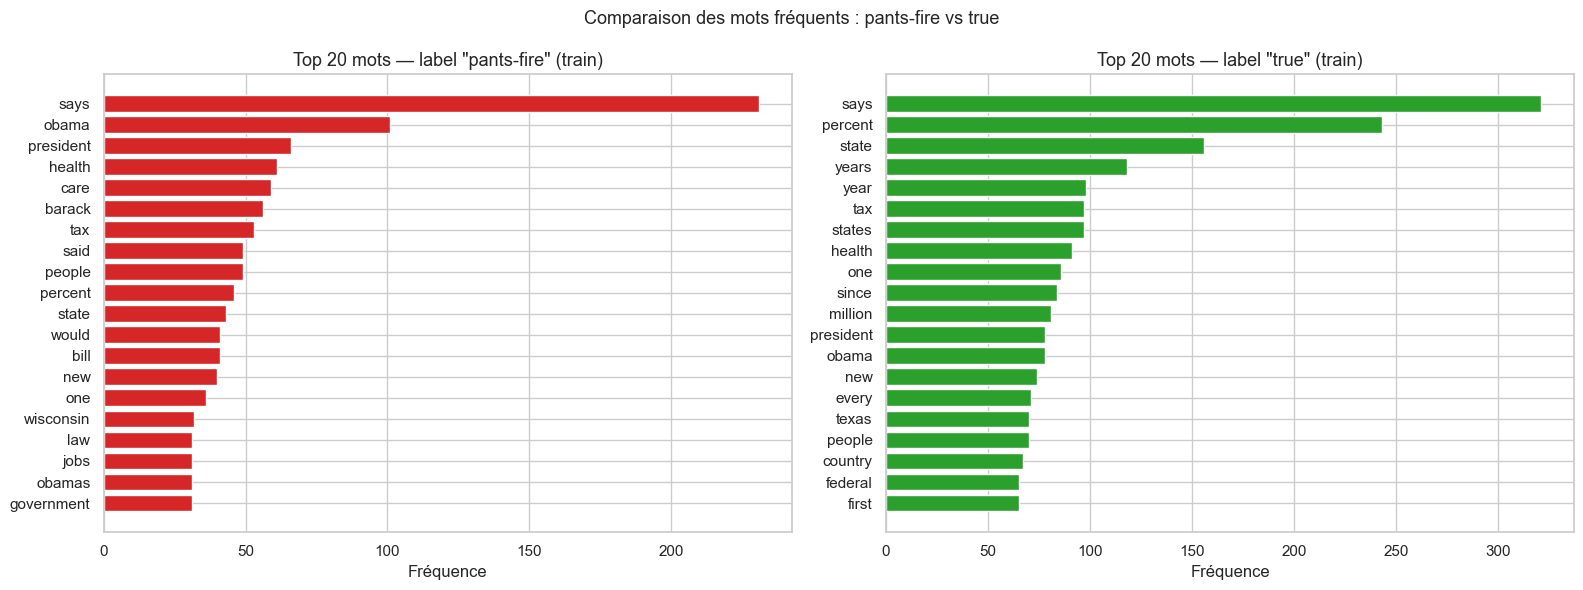

In [12]:
# Top 20 mots par label extrême : pants-fire vs true
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, target_label, color in zip(
    axes,
    ['pants-fire', 'true'],
    ['#d62728', '#2ca02c']
):
    subset = train[train['label'] == target_label]['statement'].dropna()
    tokens = []
    for stmt in subset:
        tokens.extend(tokenize_no_stop(stmt))
    top = Counter(tokens).most_common(20)
    if top:
        ws, cs = zip(*top)
        ax.barh(list(reversed(ws)), list(reversed(cs)), color=color)
    ax.set_title(f'Top 20 mots — label "{target_label}" (train)')
    ax.set_xlabel('Fréquence')

plt.suptitle('Comparaison des mots fréquents : pants-fire vs true', fontsize=13)
plt.tight_layout()
plt.show()

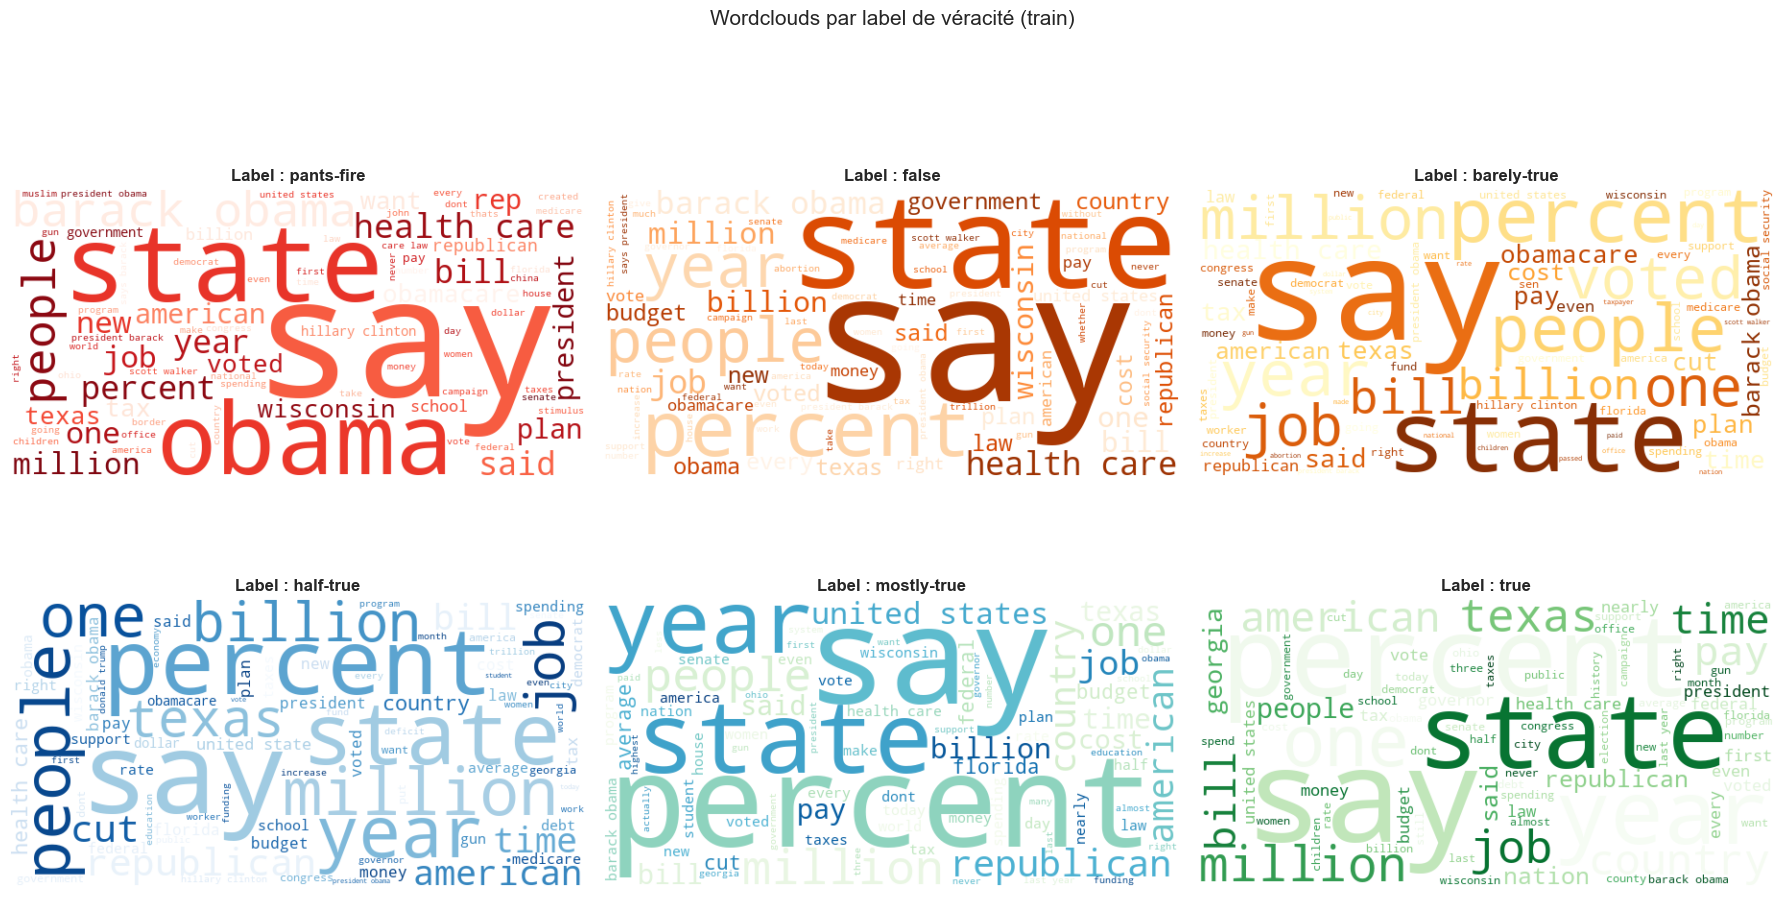

In [13]:
# Wordclouds (ou barplots si wordcloud non disponible)
if WORDCLOUD_AVAILABLE:
    wc_colors = {
        'pants-fire': 'Reds', 'false': 'Oranges', 'barely-true': 'YlOrBr',
        'half-true': 'Blues', 'mostly-true': 'GnBu', 'true': 'Greens'
    }
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()

    for ax, lbl in zip(axes, LABEL_ORDER):
        subset = train[train['label'] == lbl]['statement'].dropna()
        text = ' '.join([' '.join(tokenize_no_stop(s)) for s in subset])
        if text.strip():
            wc = WordCloud(
                width=600, height=300,
                background_color='white',
                colormap=wc_colors.get(lbl, 'viridis'),
                max_words=80
            ).generate(text)
            ax.imshow(wc, interpolation='bilinear')
        ax.axis('off')
        ax.set_title(f'Label : {lbl}', fontsize=12, fontweight='bold')

    plt.suptitle('Wordclouds par label de véracité (train)', fontsize=15, y=1.01)
    plt.tight_layout()
    plt.show()
else:
    # Fallback : barplots top-10 mots pour chaque label
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()
    for ax, lbl in zip(axes, LABEL_ORDER):
        subset = train[train['label'] == lbl]['statement'].dropna()
        tokens = []
        for s in subset:
            tokens.extend(tokenize_no_stop(s))
        top10 = Counter(tokens).most_common(10)
        if top10:
            ws, cs = zip(*top10)
            ax.barh(list(reversed(ws)), list(reversed(cs)))
        ax.set_title(f'Top 10 mots — {lbl}')
    plt.tight_layout()
    plt.show()

## 2.3 Analyse des métadonnées

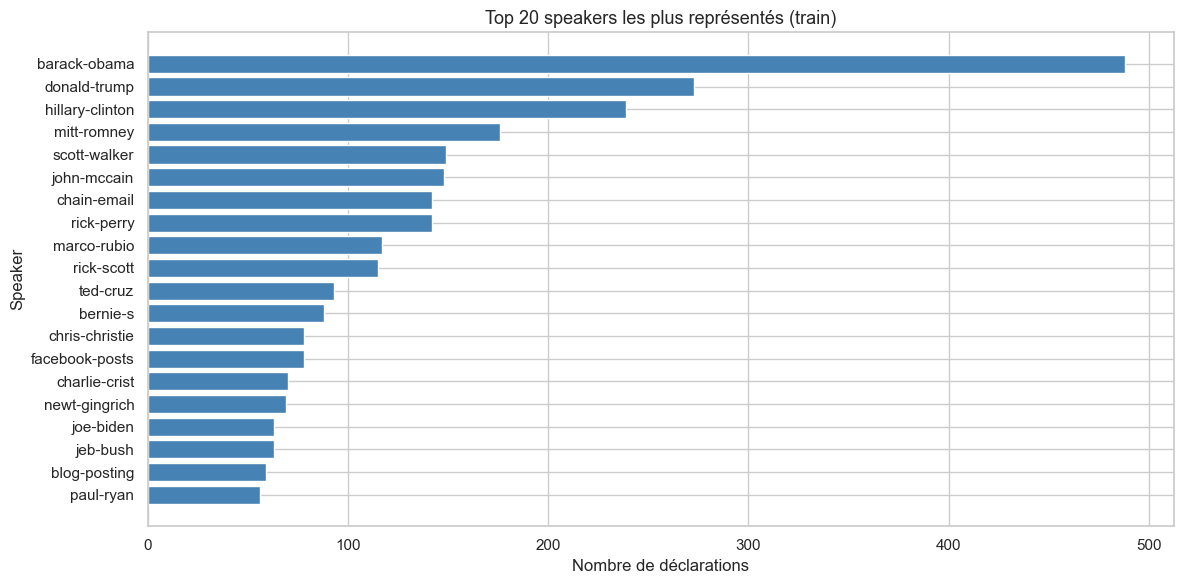

In [14]:
# Top 20 speakers les plus représentés (train)
top_speakers = train['speaker'].value_counts().head(20)

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(top_speakers.index[::-1], top_speakers.values[::-1], color='steelblue')
ax.set_title('Top 20 speakers les plus représentés (train)')
ax.set_xlabel('Nombre de déclarations')
ax.set_ylabel('Speaker')
plt.tight_layout()
plt.show()

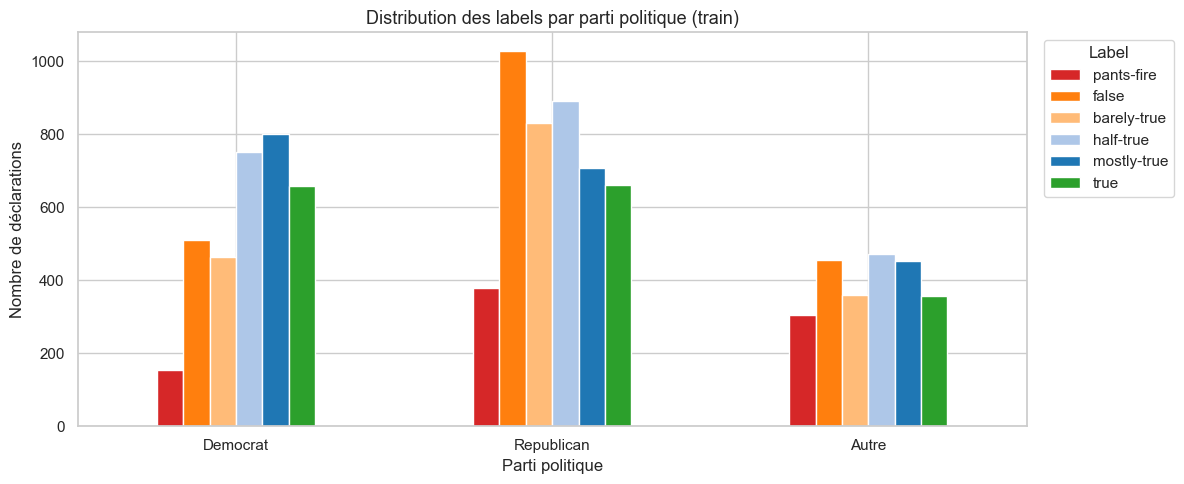

In [15]:
# Distribution des labels par parti politique
# Regroupement : Republican, Democrat, autres
def simplify_party(p):
    p = str(p).strip().lower()
    if 'republican' in p:
        return 'Republican'
    elif 'democrat' in p:
        return 'Democrat'
    else:
        return 'Autre'

train['party_group'] = train['party'].apply(simplify_party)

party_label = train.groupby(['party_group', 'label']).size().reset_index(name='count')

fig, ax = plt.subplots(figsize=(12, 5))
party_order = ['Democrat', 'Republican', 'Autre']
pivot = party_label.pivot(index='party_group', columns='label', values='count').fillna(0)
pivot = pivot.reindex(party_order).fillna(0)
pivot[LABEL_ORDER].plot(kind='bar', ax=ax, color=LABEL_COLORS, edgecolor='white')
ax.set_title('Distribution des labels par parti politique (train)')
ax.set_xlabel('Parti politique')
ax.set_ylabel('Nombre de déclarations')
ax.tick_params(axis='x', rotation=0)
ax.legend(title='Label', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

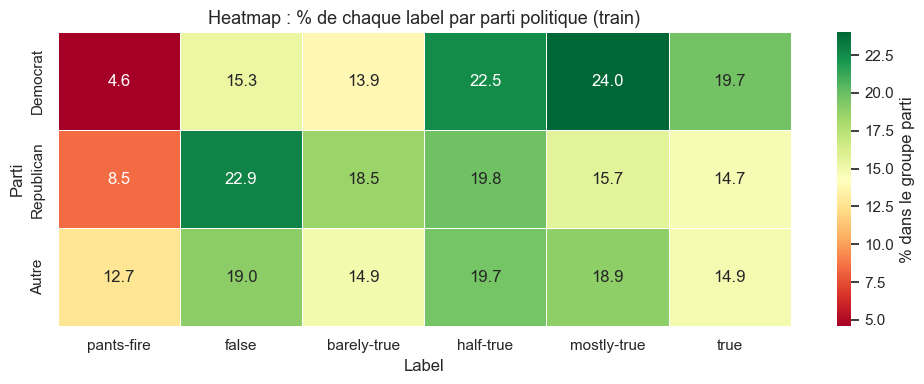

In [16]:
# Heatmap : croisement parti politique × label
pivot_pct = pivot[LABEL_ORDER].div(pivot[LABEL_ORDER].sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(
    pivot_pct,
    annot=True, fmt='.1f', cmap='RdYlGn',
    linewidths=0.5, ax=ax,
    cbar_kws={'label': '% dans le groupe parti'}
)
ax.set_title('Heatmap : % de chaque label par parti politique (train)')
ax.set_xlabel('Label')
ax.set_ylabel('Parti')
plt.tight_layout()
plt.show()

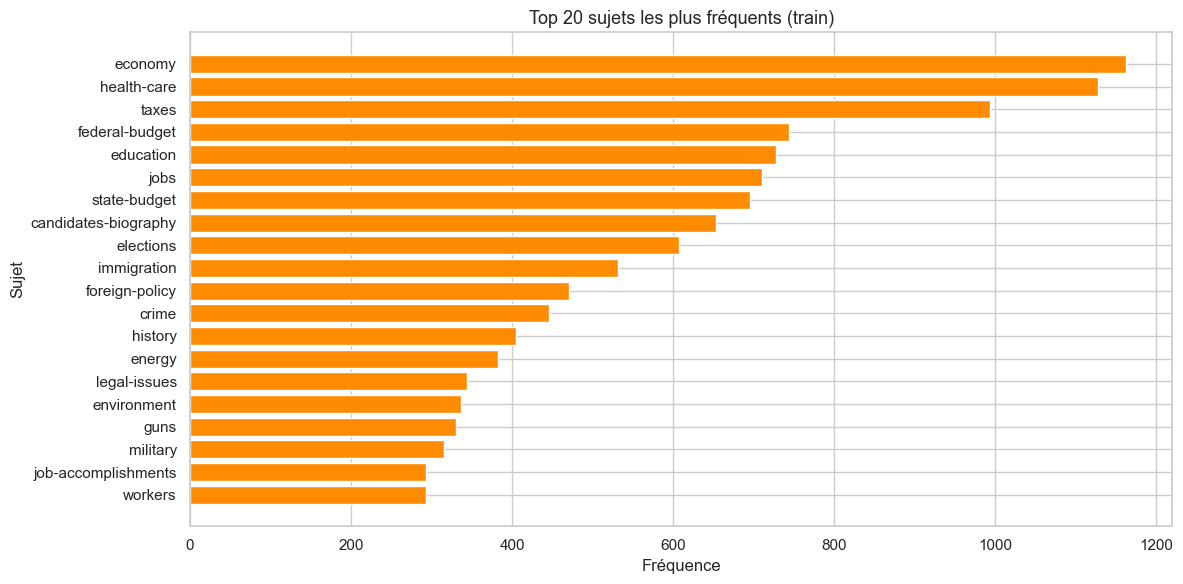

In [17]:
# Distribution des sujets (subject) les plus fréquents
# Un statement peut avoir plusieurs sujets séparés par une virgule
all_subjects = []
for s in train['subject'].dropna():
    all_subjects.extend([x.strip() for x in str(s).split(',')])

top_subjects = Counter(all_subjects).most_common(20)
sub_words, sub_counts = zip(*top_subjects)

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(list(reversed(sub_words)), list(reversed(sub_counts)), color='darkorange')
ax.set_title('Top 20 sujets les plus fréquents (train)')
ax.set_xlabel('Fréquence')
ax.set_ylabel('Sujet')
plt.tight_layout()
plt.show()

## 2.4 Analyse des compteurs historiques

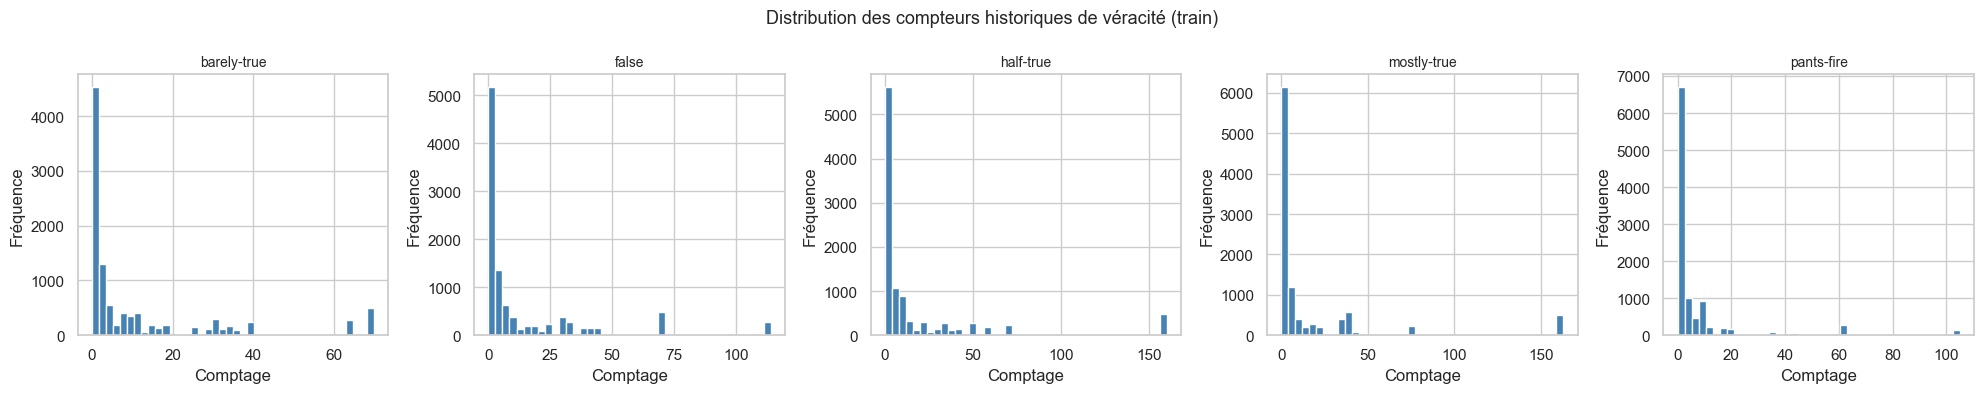

In [18]:
# Colonnes de compteurs historiques
COUNT_COLS = ['barely_true_counts', 'false_counts', 'half_true_counts',
              'mostly_true_counts', 'pants_fire_counts']

# Conversion en numérique (peuvent contenir des NaN)
for col in COUNT_COLS:
    train[col] = pd.to_numeric(train[col], errors='coerce')

# Distribution des compteurs
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, col in zip(axes, COUNT_COLS):
    data = train[col].dropna()
    ax.hist(data, bins=40, color='steelblue', edgecolor='white')
    ax.set_title(col.replace('_counts', '').replace('_', '-'), fontsize=10)
    ax.set_xlabel('Comptage')
    ax.set_ylabel('Fréquence')

plt.suptitle('Distribution des compteurs historiques de véracité (train)', fontsize=13)
plt.tight_layout()
plt.show()

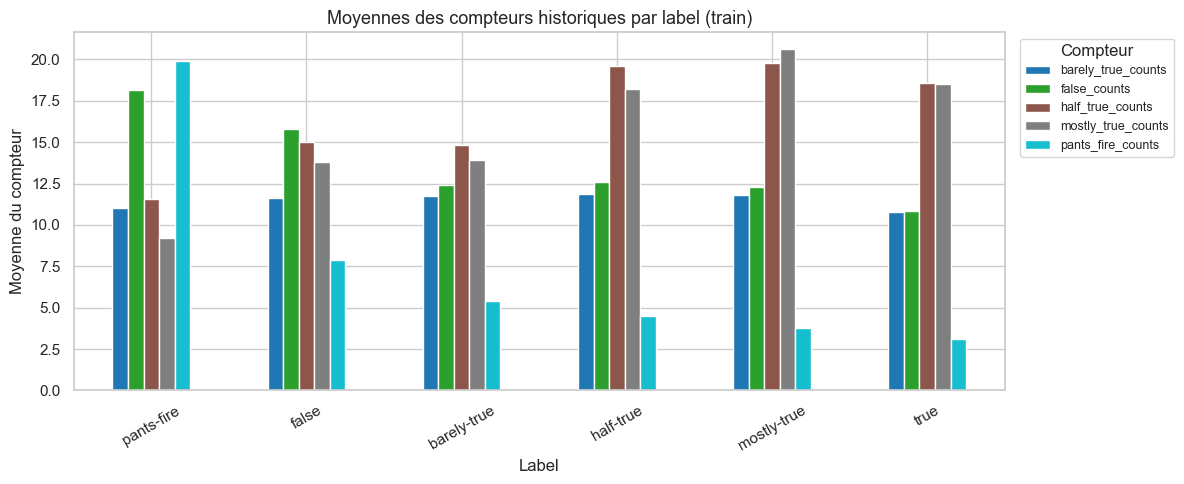

In [19]:
# Moyennes des compteurs par label
count_by_label = train.groupby('label')[COUNT_COLS].mean().reindex(LABEL_ORDER)

fig, ax = plt.subplots(figsize=(12, 5))
count_by_label.plot(kind='bar', ax=ax, colormap='tab10', edgecolor='white')
ax.set_title('Moyennes des compteurs historiques par label (train)')
ax.set_xlabel('Label')
ax.set_ylabel('Moyenne du compteur')
ax.tick_params(axis='x', rotation=30)
ax.legend(title='Compteur', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

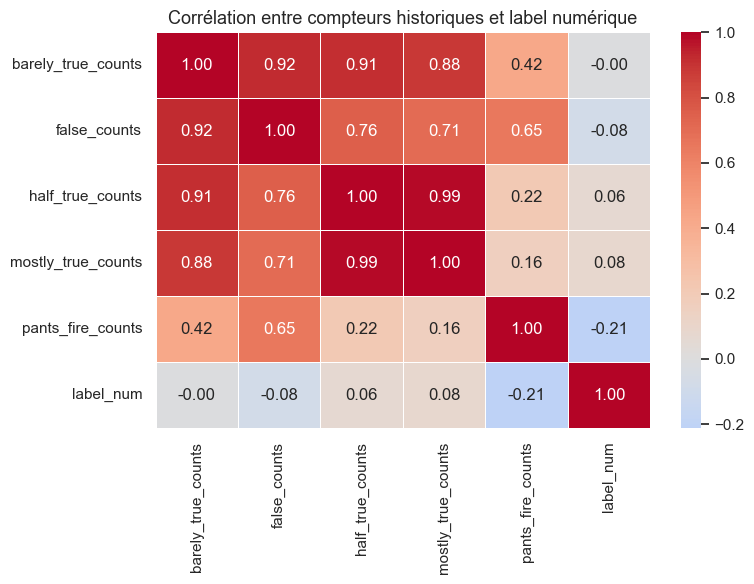

In [20]:
# Corrélation entre compteurs et label (encodé numériquement pour le calcul)
label_num_map = {l: i for i, l in enumerate(LABEL_ORDER)}
train['label_num'] = train['label'].map(label_num_map)

corr_data = train[COUNT_COLS + ['label_num']].dropna()
corr_matrix = corr_data.corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
    center=0, linewidths=0.5, ax=ax
)
ax.set_title('Corrélation entre compteurs historiques et label numérique')
plt.tight_layout()
plt.show()

## 2.5 Détection des valeurs manquantes

In [21]:
# Pourcentage de nulls par colonne pour chaque split
print('=== Pourcentage de valeurs nulles par colonne ===')
null_summary = pd.DataFrame({
    name: df[COLUMNS].isnull().mean() * 100
    for name, df in splits.items()
})
print(null_summary.round(2).to_string())

=== Pourcentage de valeurs nulles par colonne ===
                    train   test  valid
id                   0.00   0.00   0.00
label                0.00   0.00   0.00
statement            0.00   0.00   0.00
subject              0.02   0.00   0.00
speaker              0.02   0.00   0.00
job_title           28.30  25.65  26.87
state               21.58  20.68  21.73
party                0.02   0.00   0.00
barely_true_counts   0.02   0.00   0.00
false_counts         0.02   0.00   0.00
half_true_counts     0.02   0.00   0.00
mostly_true_counts   0.02   0.00   0.00
pants_fire_counts    0.02   0.00   0.00
context              1.00   1.34   0.93


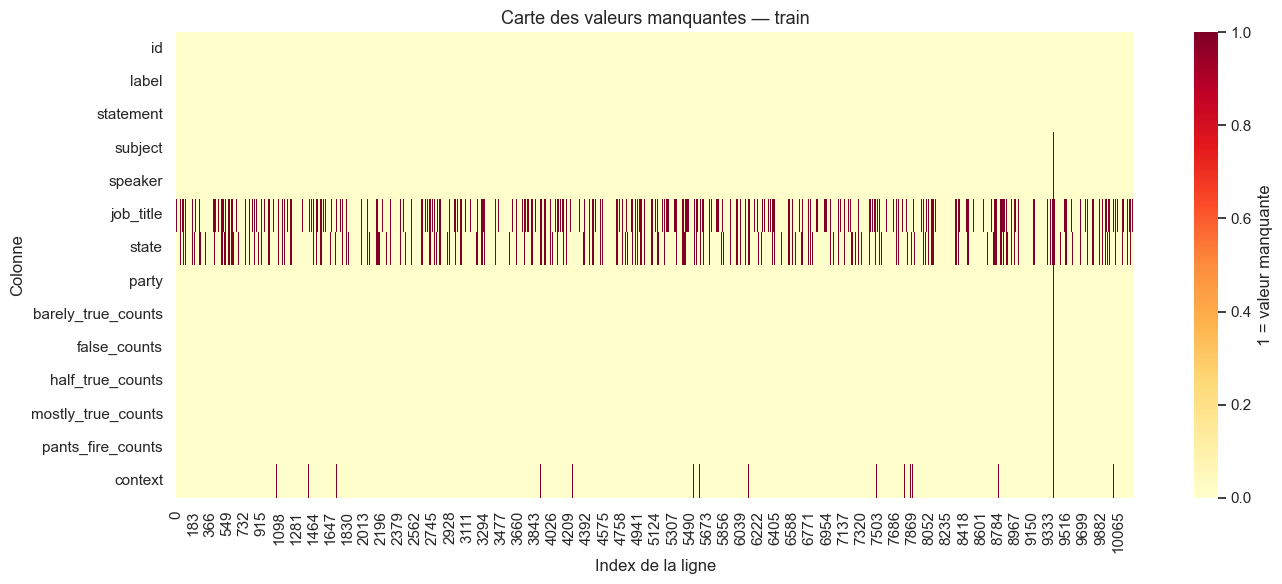

In [22]:
# Heatmap des valeurs nulles (train)
null_matrix = train[COLUMNS].isnull().astype(int)

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(
    null_matrix.T,
    cmap='YlOrRd', cbar_kws={'label': '1 = valeur manquante'},
    linewidths=0, ax=ax
)
ax.set_title('Carte des valeurs manquantes — train')
ax.set_xlabel('Index de la ligne')
ax.set_ylabel('Colonne')
plt.tight_layout()
plt.show()

---
# ÉTAPE 3 — Preprocessing

## 3.1 Nettoyage du texte

In [23]:
# Initialisation du lemmatizer et des stopwords
lemmatizer = WordNetLemmatizer()
stop_words_set = set(stopwords.words('english'))

def clean_text(text):
    """Pipeline de nettoyage complet d'un statement.

    Étapes :
    1. Conversion en string et lowercase
    2. Suppression de la ponctuation et des caractères spéciaux
    3. Suppression des stopwords
    4. Lemmatisation
    """
    # 1. Lowercase
    text = str(text).lower()
    # 2. Suppression de la ponctuation et caractères non-alphabétiques
    text = re.sub(r'[^a-z\s]', '', text)
    # 3. Tokenisation
    tokens = text.split()
    # 4. Suppression des stopwords et mots trop courts
    tokens = [t for t in tokens if t not in stop_words_set and len(t) > 2]
    # 5. Lemmatisation
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return ' '.join(tokens)

print('Fonction clean_text définie. Test rapide :')
test_stmt = "The President said he would never raise taxes on the middle-class families!"
print(f'  Original : {test_stmt}')
print(f'  Nettoyé  : {clean_text(test_stmt)}')

Fonction clean_text définie. Test rapide :
  Original : The President said he would never raise taxes on the middle-class families!
  Nettoyé  : president said would never raise tax middleclass family


In [24]:
# Application du nettoyage sur les 3 splits
# Note : les compteurs sont aussi convertis en numérique ici
for name, df in splits.items():
    # Nettoyage du texte
    df['clean_statement'] = df['statement'].apply(clean_text)
    # Conversion des compteurs en numérique
    for col in COUNT_COLS:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    print(f'{name:6s} : clean_statement créée. Exemple : {df["clean_statement"].iloc[0][:80]}...')

train  : clean_statement créée. Exemple : say annies list political group support thirdtrimester abortion demand...
test   : clean_statement créée. Exemple : building wall usmexico border take literally year...
valid  : clean_statement créée. Exemple : less american working...


## 3.2 Mapping des labels

In [25]:
# label_binary : 0 = fake, 1 = real
BINARY_MAP = {
    'pants-fire': 0, 'false': 0, 'barely-true': 0,  # fake
    'half-true': 1, 'mostly-true': 1, 'true': 1      # real
}

# label_3class : 0 = faux, 1 = mixte, 2 = vrai
TRICLASS_MAP = {
    'pants-fire': 0, 'false': 0,         # faux
    'barely-true': 1, 'half-true': 1,    # mixte
    'mostly-true': 2, 'true': 2          # vrai
}

for name, df in splits.items():
    df['label_binary']  = df['label'].map(BINARY_MAP)
    df['label_3class']  = df['label'].map(TRICLASS_MAP)

print('Mappings des labels appliqués. Distribution label_binary (train) :')
print(train['label_binary'].value_counts().rename({0: 'fake (0)', 1: 'real (1)'}).to_string())

print('\nDistribution label_3class (train) :')
print(train['label_3class'].value_counts().rename({0: 'faux (0)', 1: 'mixte (1)', 2: 'vrai (2)'}).to_string())

Mappings des labels appliqués. Distribution label_binary (train) :
label_binary
real (1)    5752
fake (0)    4488

Distribution label_3class (train) :
label_3class
mixte (1)    3768
vrai (2)     3638
faux (0)     2834


## 3.3 Encodage des métadonnées

In [26]:
# Encodage du parti politique : Republican=0, Democrat=1, autres=2
PARTY_ENCODE = {'Republican': 0, 'Democrat': 1, 'Autre': 2}

for name, df in splits.items():
    df['party_group'] = df['party'].apply(simplify_party)
    df['party_encoded'] = df['party_group'].map(PARTY_ENCODE)

print('Encodage du parti politique :')
print(train[['party', 'party_group', 'party_encoded']].drop_duplicates().head(10).to_string(index=False))

Encodage du parti politique :
         party party_group  party_encoded
    republican  Republican              0
      democrat    Democrat              1
          none       Autre              2
  organization       Autre              2
   independent       Autre              2
     columnist       Autre              2
      activist       Autre              2
talk-show-host       Autre              2
   libertarian       Autre              2
     newsmaker       Autre              2


## 3.4 Vérification finale

In [27]:
# Shape avant/après (les colonnes ajoutées augmentent la largeur)
ORIGINAL_COLS = COLUMNS
ADDED_COLS = ['clean_statement', 'label_binary', 'label_3class', 'party_group', 'party_encoded']

print('=== Shape avant / après preprocessing ===')
for name, df in splits.items():
    print(f'  {name:6s} : {len(ORIGINAL_COLS)} colonnes originales → {df.shape[1]} colonnes totales ({df.shape[0]} lignes)')

=== Shape avant / après preprocessing ===
  train  : 14 colonnes originales → 22 colonnes totales (10240 lignes)
  test   : 14 colonnes originales → 19 colonnes totales (1267 lignes)
  valid  : 14 colonnes originales → 19 colonnes totales (1284 lignes)


In [28]:
# Vérification des nulls dans clean_statement
print('=== Valeurs nulles dans clean_statement ===')
for name, df in splits.items():
    n_null = df['clean_statement'].isnull().sum()
    n_empty = (df['clean_statement'] == '').sum()
    print(f'  {name:6s} : {n_null} null, {n_empty} chaînes vides')

=== Valeurs nulles dans clean_statement ===
  train  : 0 null, 0 chaînes vides
  test   : 0 null, 0 chaînes vides
  valid  : 0 null, 0 chaînes vides


In [29]:
# 5 exemples côte à côte : statement original vs clean_statement
print('=== 5 exemples : statement original vs clean_statement (train) ===')
examples = train[['statement', 'clean_statement', 'label', 'label_binary', 'label_3class']].head(5)
pd.set_option('display.max_colwidth', 80)
display(examples)

=== 5 exemples : statement original vs clean_statement (train) ===


,statement,clean_statement,label,label_binary,label_3class
0,Says the Annies List political group supports third-trimester abortions on d...,say annies list political group support thirdtrimester abortion demand,false,0,0
1,When did the decline of coal start? It started when natural gas took off tha...,decline coal start started natural gas took started begin president george b...,half-true,1,1
2,"Hillary Clinton agrees with John McCain ""by voting to give George Bush the b...",hillary clinton agrees john mccain voting give george bush benefit doubt iran,mostly-true,1,2
3,Health care reform legislation is likely to mandate free sex change surgeries.,health care reform legislation likely mandate free sex change surgery,false,0,0
4,The economic turnaround started at the end of my term.,economic turnaround started end term,half-true,1,1


---
# ÉTAPE 4 — Export vers 02_stg/

In [30]:
# Colonnes finales à exporter
EXPORT_COLS = COLUMNS + ADDED_COLS

export_map = {
    'train': train,
    'test':  test,
    'valid': valid
}

exported_paths = []

for name, df in export_map.items():
    # Sélection des colonnes disponibles (certaines ajoutées seulement sur train au début)
    cols_to_export = [c for c in EXPORT_COLS if c in df.columns]
    out_path = STG_DIR / f'{name}_clean.csv'
    df[cols_to_export].to_csv(out_path, index=False)
    exported_paths.append(out_path)
    print(f'Export : {out_path}  →  shape {df[cols_to_export].shape}')

print('\nExport terminé.')

Export : C:\Users\HugoG\Documents\GitHub\projet_spe_3_fake_new\LIAR_DATA_SET\02_stg\train_clean.csv  →  shape (10240, 19)
Export : C:\Users\HugoG\Documents\GitHub\projet_spe_3_fake_new\LIAR_DATA_SET\02_stg\test_clean.csv  →  shape (1267, 19)
Export : C:\Users\HugoG\Documents\GitHub\projet_spe_3_fake_new\LIAR_DATA_SET\02_stg\valid_clean.csv  →  shape (1284, 19)

Export terminé.


In [31]:
# Résumé final
print('=' * 60)
print('RÉSUMÉ FINAL — Fichiers exportés dans 02_stg/')
print('=' * 60)

for path in exported_paths:
    df_check = pd.read_csv(path)
    print(f'\nFichier : {path.name}')
    print(f'  Chemin : {path}')
    print(f'  Shape  : {df_check.shape}')
    print(f'  Colonnes : {list(df_check.columns)}')
    display(df_check.head(3))

RÉSUMÉ FINAL — Fichiers exportés dans 02_stg/

Fichier : train_clean.csv
  Chemin : C:\Users\HugoG\Documents\GitHub\projet_spe_3_fake_new\LIAR_DATA_SET\02_stg\train_clean.csv
  Shape  : (10240, 19)
  Colonnes : ['id', 'label', 'statement', 'subject', 'speaker', 'job_title', 'state', 'party', 'barely_true_counts', 'false_counts', 'half_true_counts', 'mostly_true_counts', 'pants_fire_counts', 'context', 'clean_statement', 'label_binary', 'label_3class', 'party_group', 'party_encoded']


,id,label,statement,subject,speaker,job_title,state,party,barely_true_counts,false_counts,half_true_counts,mostly_true_counts,pants_fire_counts,context,clean_statement,label_binary,label_3class,party_group,party_encoded
0,2635.json,false,Says the Annies List political group supports third-trimester abortions on d...,abortion,dwayne-bohac,State representative,Texas,republican,0.0,1.0,0.0,0.0,0.0,a mailer,say annies list political group support thirdtrimester abortion demand,0,0,Republican,0
1,10540.json,half-true,When did the decline of coal start? It started when natural gas took off tha...,"energy,history,job-accomplishments",scott-surovell,State delegate,Virginia,democrat,0.0,0.0,1.0,1.0,0.0,a floor speech.,decline coal start started natural gas took started begin president george b...,1,1,Democrat,1
2,324.json,mostly-true,"Hillary Clinton agrees with John McCain ""by voting to give George Bush the b...",foreign-policy,barack-obama,President,Illinois,democrat,70.0,71.0,160.0,163.0,9.0,Denver,hillary clinton agrees john mccain voting give george bush benefit doubt iran,1,2,Democrat,1



Fichier : test_clean.csv
  Chemin : C:\Users\HugoG\Documents\GitHub\projet_spe_3_fake_new\LIAR_DATA_SET\02_stg\test_clean.csv
  Shape  : (1267, 19)
  Colonnes : ['id', 'label', 'statement', 'subject', 'speaker', 'job_title', 'state', 'party', 'barely_true_counts', 'false_counts', 'half_true_counts', 'mostly_true_counts', 'pants_fire_counts', 'context', 'clean_statement', 'label_binary', 'label_3class', 'party_group', 'party_encoded']


,id,label,statement,subject,speaker,job_title,state,party,barely_true_counts,false_counts,half_true_counts,mostly_true_counts,pants_fire_counts,context,clean_statement,label_binary,label_3class,party_group,party_encoded
0,11972.json,true,Building a wall on the U.S.-Mexico border will take literally years.,immigration,rick-perry,Governor,Texas,republican,30,30,42,23,18,Radio interview,building wall usmexico border take literally year,1,2,Republican,0
1,11685.json,false,Wisconsin is on pace to double the number of layoffs this year.,jobs,katrina-shankland,State representative,Wisconsin,democrat,2,1,0,0,0,a news conference,wisconsin pace double number layoff year,0,0,Democrat,1
2,11096.json,false,Says John McCain has done nothing to help the vets.,"military,veterans,voting-record",donald-trump,President-Elect,New York,republican,63,114,51,37,61,comments on ABC's This Week.,say john mccain done nothing help vet,0,0,Republican,0



Fichier : valid_clean.csv
  Chemin : C:\Users\HugoG\Documents\GitHub\projet_spe_3_fake_new\LIAR_DATA_SET\02_stg\valid_clean.csv
  Shape  : (1284, 19)
  Colonnes : ['id', 'label', 'statement', 'subject', 'speaker', 'job_title', 'state', 'party', 'barely_true_counts', 'false_counts', 'half_true_counts', 'mostly_true_counts', 'pants_fire_counts', 'context', 'clean_statement', 'label_binary', 'label_3class', 'party_group', 'party_encoded']


,id,label,statement,subject,speaker,job_title,state,party,barely_true_counts,false_counts,half_true_counts,mostly_true_counts,pants_fire_counts,context,clean_statement,label_binary,label_3class,party_group,party_encoded
0,12134.json,barely-true,We have less Americans working now than in the 70s.,"economy,jobs",vicky-hartzler,U.S. Representative,Missouri,republican,1,0,1,0,0,an interview with ABC17 News,less american working,0,1,Republican,0
1,238.json,pants-fire,"When Obama was sworn into office, he DID NOT use the Holy Bible, but instead...","obama-birth-certificate,religion",chain-email,NaN,NaN,none,11,43,8,5,105,NaN,obama sworn office use holy bible instead kuran equivalency bible different ...,0,0,Autre,2
2,7891.json,false,Says Having organizations parading as being social welfare organizations and...,"campaign-finance,congress,taxes",earl-blumenauer,U.S. representative,Oregon,democrat,0,1,1,1,0,a U.S. Ways and Means hearing,say organization parading social welfare organization involved political com...,0,0,Democrat,1
